#***Introduction***
In the context of YouTube’s rapid growth, understanding the factors that influence video performance is essential for content creators. The number of views not only reflects a video’s popularity but also serves as a key metric for evaluating its success.

This analysis focuses on a dataset of trending YouTube videos to explore the factors that affect view counts, including upload timing, content category, engagement levels such as likes and comments, and other video-related features.

Through data cleaning, exploratory data analysis (EDA), relationship analysis between variables, and Machine Learning model development, the project aims to:

* Understand the distribution of video views
* Identify the key factors influencing video performance
* Generate insights and recommendations to optimize content publishing strategies

The results of this analysis not only provide a better understanding of viewer behavior but also offer a data-driven foundation for making strategic decisions related to content development, upload timing optimization, and improving audience reach on the YouTube platform.


##**IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

##**LOAD DATA**

###***Upload file***

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/[CS Data 12][Đồ_án_cuối_khóa]/youtube.csv')

df.head() # Xem 5 dòng đầu của dataset

,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,13/11/2017,17:00 to 17:59,Monday,US,SHANtell martin,748374,57527,2966,15954,False,False,False
1,1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,13/11/2017,7:00 to 7:59,Monday,US,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,False,False,False
2,2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,12/11/2017,19:00 to 19:59,Sunday,US,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",3191434,146033,5339,8181,False,False,False
3,3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,13/11/2017,11:00 to 11:59,Monday,US,"rhett and link|""gmm""""|""""good mythical morning""...",343168,10172,666,2146,False,False,False
4,4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,12/11/2017,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",2095731,132235,1989,17518,False,False,False


In [ ]:
df.shape # Kích thước dữ liệu (số dòng, số cột)

(161470, 18)

In [ ]:
df.columns # Danh sách tên các cột

Index(['index', 'video_id', 'trending_date', 'title', 'channel_title',
       'category_id', 'publish_date', 'time_frame', 'published_day_of_week',
       'publish_country', 'tags', 'views', 'likes', 'dislikes',
       'comment_count', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed'],
      dtype='object')

In [ ]:
df.info()  # Kiểu dữ liệu và số lượng giá trị non-null của từng cột

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161470 entries, 0 to 161469
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   index                   161470 non-null  int64 
 1   video_id                161470 non-null  object
 2   trending_date           161470 non-null  object
 3   title                   161470 non-null  object
 4   channel_title           161470 non-null  object
 5   category_id             161470 non-null  int64 
 6   publish_date            161470 non-null  object
 7   time_frame              161470 non-null  object
 8   published_day_of_week   161470 non-null  object
 9   publish_country         161470 non-null  object
 10  tags                    161470 non-null  object
 11  views                   161470 non-null  int64 
 12  likes                   161470 non-null  int64 
 13  dislikes                161470 non-null  int64 
 14  comment_count           161470 non-n

In [ ]:
df = df.drop(columns=['index'])  # Xóa cột index không cần thiết
df.info()  # Kiểm tra kiểu dữ liệu và số lượng giá trị non-null của từng cột sau khi đã drop index

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161470 entries, 0 to 161469
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   video_id                161470 non-null  object
 1   trending_date           161470 non-null  object
 2   title                   161470 non-null  object
 3   channel_title           161470 non-null  object
 4   category_id             161470 non-null  int64 
 5   publish_date            161470 non-null  object
 6   time_frame              161470 non-null  object
 7   published_day_of_week   161470 non-null  object
 8   publish_country         161470 non-null  object
 9   tags                    161470 non-null  object
 10  views                   161470 non-null  int64 
 11  likes                   161470 non-null  int64 
 12  dislikes                161470 non-null  int64 
 13  comment_count           161470 non-null  int64 
 14  comments_disabled       161470 non-n

In [ ]:
df.describe() # Thống kê mô tả các cột dạng số

,category_id,views,likes,dislikes,comment_count
count,161470.000000,1.614700e+05,1.614700e+05,1.614700e+05,1.614700e+05
mean,19.461151,2.419854e+06,6.566194e+04,3.490153e+03,7.035494e+03
std,7.432001,1.043749e+07,2.260617e+05,3.114779e+04,3.404121e+04
min,1.000000,2.230000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,15.000000,1.015382e+05,1.975000e+03,8.500000e+01,2.790000e+02
50%,23.000000,3.847395e+05,9.840000e+03,3.480000e+02,1.144000e+03
75%,24.000000,1.339528e+06,4.006275e+04,1.350000e+03,4.144750e+03
max,44.000000,4.245389e+08,5.613827e+06,1.944971e+06,1.626501e+06


##**DATA CLEANING**

In [ ]:
df.isnull().sum()  # Kiểm tra số lượng giá trị bị thiếu ở mỗi cột

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_date,0
time_frame,0
published_day_of_week,0
publish_country,0
tags,0


***The dataset contains no missing values.***

In [ ]:
df.duplicated().sum()  # Đếm số dòng bị trùng lặp

np.int64(219)

***Duplicate data is present in the dataset.***

In [ ]:
df = df.drop_duplicates()  # Xóa các dòng trùng lặp hoàn toàn
df.duplicated().sum()  # Kiểm tra lại số dòng trùng lặp

np.int64(0)

In [ ]:
df[['publish_date', 'trending_date']].head(10) #Check fomat của 2 cột 'publish_date' và 'trending_date'

,publish_date,trending_date
0,13/11/2017,17.14.11
1,13/11/2017,17.14.11
2,12/11/2017,17.14.11
3,13/11/2017,17.14.11
4,12/11/2017,17.14.11
5,13/11/2017,17.14.11
6,12/11/2017,17.14.11
7,12/11/2017,17.14.11
8,13/11/2017,17.14.11
9,13/11/2017,17.14.11


In [ ]:
df['publish_date'] = pd.to_datetime(df['publish_date'], dayfirst=True, errors='coerce')  # Format dd/mm/yyyy
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m', errors='coerce')  # Format yy.dd.mm

In [ ]:
# Check lỗi sau khi convert
df['publish_date'].isnull().sum()
df['trending_date'].isnull().sum()

np.int64(0)

In [ ]:
df[['publish_date', 'trending_date']].head(10)  # Xem 10 giá trị đầu của 2 cột ngày

,publish_date,trending_date
0,2017-11-13,2017-11-14
1,2017-11-13,2017-11-14
2,2017-11-12,2017-11-14
3,2017-11-13,2017-11-14
4,2017-11-12,2017-11-14
5,2017-11-13,2017-11-14
6,2017-11-12,2017-11-14
7,2017-11-12,2017-11-14
8,2017-11-13,2017-11-14
9,2017-11-13,2017-11-14


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 161251 entries, 0 to 161469
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   video_id                161251 non-null  object        
 1   trending_date           161251 non-null  datetime64[ns]
 2   title                   161251 non-null  object        
 3   channel_title           161251 non-null  object        
 4   category_id             161251 non-null  int64         
 5   publish_date            161251 non-null  datetime64[ns]
 6   time_frame              161251 non-null  object        
 7   published_day_of_week   161251 non-null  object        
 8   publish_country         161251 non-null  object        
 9   tags                    161251 non-null  object        
 10  views                   161251 non-null  int64         
 11  likes                   161251 non-null  int64         
 12  dislikes                161251 non-

##***Data Cleaning Summary***

After the data cleaning process:

* The dataset contains no missing values.
* Duplicate records were removed to ensure data accuracy.
* Time-related columns were converted to the datetime format for further analysis.
* The dataset is now ready for analysis and model development.



##**FEATURE ENGINEERING**

***Creating Time-Based Features from publish_date***

In [ ]:
df['publish_hour'] = df['publish_date'].dt.hour        # Giờ đăng video
df['publish_day'] = df['publish_date'].dt.day_name()   # Ngày trong tuần
df['publish_month'] = df['publish_date'].dt.month      # Tháng đăng video

***Calculating the Number of Days from Video Publication to Trending***

In [ ]:
df['days_to_trending'] = (df['trending_date'] - df['publish_date']).dt.days  # Số ngày để lên trending

***Creating Video Engagement Features***

In [ ]:
df['like_ratio'] = df['likes'] / df['views']              # Tỷ lệ like
df['comment_ratio'] = df['comment_count'] / df['views']   # Tỷ lệ comment

***Creating Content-Based Features from Video Titles and Tags***

In [ ]:
df['title_length'] = df['title'].astype(str).apply(len)   # Độ dài tiêu đề
df['num_tags'] = df['tags'].astype(str).apply(lambda x: len(x.split('|')))  # Số lượng tag

***Reviewing the Newly Created Features***

In [ ]:
df[['publish_hour', 'publish_day', 'days_to_trending', 'like_ratio', 'title_length']].head()

,publish_hour,publish_day,days_to_trending,like_ratio,title_length
0,0,Monday,1,0.076869,34
1,0,Monday,1,0.040179,62
2,0,Sunday,2,0.045758,53
3,0,Monday,1,0.029641,32
4,0,Sunday,2,0.063097,24


##***EDA***

***Distribution of Video View Counts***

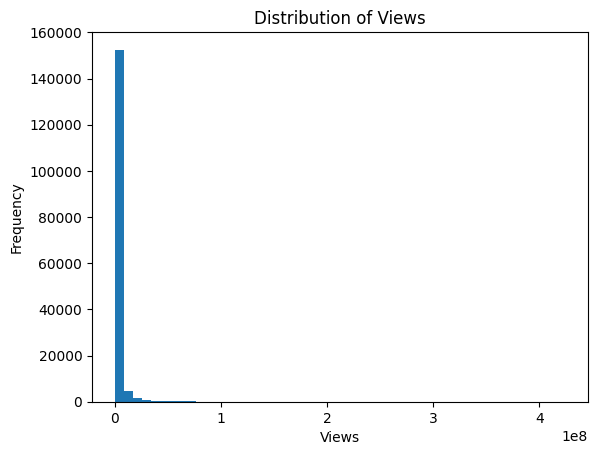

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['views'], bins=50)
plt.title("Distribution of Views")
plt.xlabel("Views")
plt.ylabel("Frequency")
plt.show()

**Distribution of Views**

The chart shows that the distribution of video views is right-skewed. Most videos have relatively low view counts, while only a small number of videos achieve extremely high numbers of views. This reflects a common pattern on social media platforms, where only a small proportion of content goes viral and captures most of the audience’s attention.

In addition, because the data is highly skewed with a long tail extending to the right, the original chart makes it difficult to clearly observe the distribution. Therefore, applying a **log transformation** helps reduce the skewness and makes the distribution easier to visualize and interpret.


***Distribution of Views After Log Transformation to Reduce Skewness***

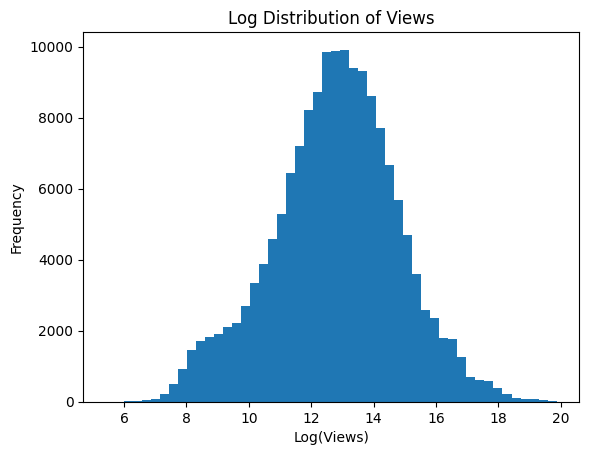

In [ ]:
plt.figure()
plt.hist(np.log1p(df['views']), bins=50) # Dùng log1p để giảm độ lệch của dữ liệu (log(1 + x))
plt.title("Log Distribution of Views")
plt.xlabel("Log(Views)")
plt.ylabel("Frequency")
plt.show()

After applying the log transformation, the data distribution becomes more balanced and closer to a normal distribution.

The chart shows that the data is no longer as heavily skewed as before, making it easier to visualize and analyze. This indicates that log transformation is an appropriate technique for handling highly skewed data.


***Comparing Average View Counts Across Categories***

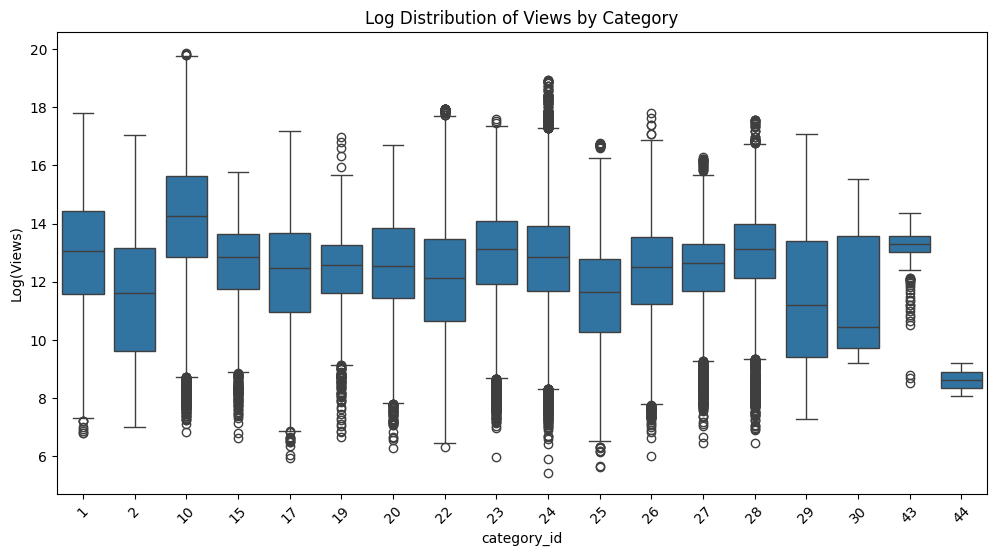

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='category_id', y=np.log1p(df['views']), data=df)
plt.title("Log Distribution of Views by Category")
plt.ylabel("Log(Views)")
plt.xticks(rotation=45)
plt.show()

**Average Views by Category**

Some categories, such as 10, 24, and 28, have higher median view counts than the others, indicating that videos in these content groups tend to achieve higher typical viewership. These categories also contain many extremely high outliers, suggesting a greater potential to generate viral videos. Therefore, they not only perform well on average but also have strong breakout potential.

In contrast, categories such as 44 have a lower median and a narrower distribution, indicating lower and more stable view counts, with less potential for producing viral content. In addition, differences in box height across categories show varying levels of dispersion, reflecting inconsistencies in content performance among video groups.

Overall, content category is an important factor influencing video views. Certain categories demonstrate both stronger overall performance and a greater likelihood of producing videos with exceptionally high view counts.


***Distribution of the Number of Videos by Day of the Week***

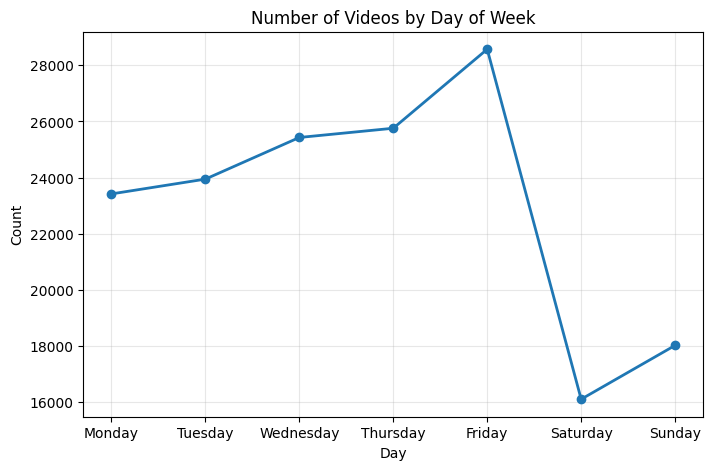

In [ ]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(8,5))

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['publish_day'].value_counts().reindex(order).plot(marker='o', linewidth=2)

plt.title("Number of Videos by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")

plt.grid(alpha=0.3)

plt.show()

**Number of Videos by Day of the Week**

The number of uploaded videos tends to increase gradually from the beginning of the week and reaches its peak on Friday. This suggests that content creators prefer publishing videos near the end of the working week to maximize audience reach.

In contrast, the number of videos drops sharply on Saturday and remains relatively low on Sunday, indicating a significant decline in content-uploading activity during the weekend. This difference reflects a common creator behavior of prioritizing weekdays over weekends for video publication.

However, the lower number of videos uploaded during the weekend may also create an opportunity for reduced competition, allowing videos published at this time to attract more attention.


***Average Views by Publication Day***

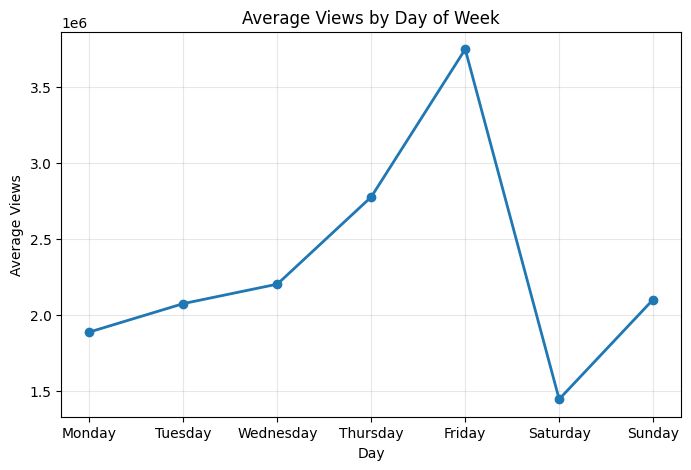

In [ ]:
plt.figure(figsize=(8,5))

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df.groupby('publish_day')['views'].mean().reindex(order).plot(marker='o', linewidth=2)

plt.title("Average Views by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Views")
plt.grid(alpha=0.3)

plt.show()

**Average Views by Video Publication Day**

Average views tend to increase gradually from the beginning of the week and reach their highest level on Friday, suggesting that this is the most effective day to publish videos in order to maximize viewership.

In contrast, although fewer videos are uploaded on Saturday, the average number of views also drops significantly, indicating weaker content performance on that day. This suggests that both upload volume and content effectiveness peak near the end of the working week, especially on Friday, while the actual weekend, particularly Saturday and Sunday, is not the optimal period for achieving high view counts.

Overall, the day of publication, especially Thursday and Friday, appears to have a positive influence on video performance.


**Analysis by Video Publication Day**

By combining the two charts showing the number of uploaded videos and the average views by day of the week, a clear difference can be observed between uploading behavior and audience engagement performance. Content creators tend to publish more videos on weekdays, particularly from Wednesday to Friday, with the highest upload volume occurring on Friday. At the same time, average views also increase throughout this period and reach their highest level on Friday, indicating that it is the most effective day in terms of both upload activity and video performance.

However, during the weekend, especially on Saturday, both the number of uploaded videos and average views decline significantly, suggesting that it is not an effective time to publish content. In contrast, although fewer videos are uploaded on Sunday, the average number of views remains relatively stable, indicating potentially lower competition.

Overall, the results show that publishing a larger number of videos does not necessarily guarantee better performance. The timing of publication plays an important role in optimizing view counts. Content creators should therefore select suitable publishing times to balance competition levels with the ability to reach viewers.


##***Correlation Analysis***

***Calculating and Visualizing the Correlation Matrix Between Numerical Variables***

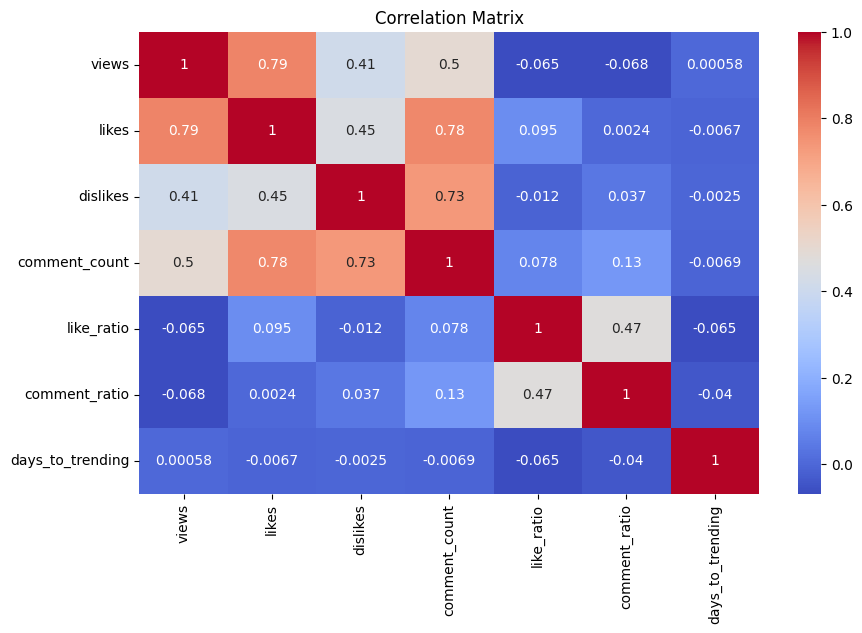

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
corr = df[['views', 'likes', 'dislikes', 'comment_count', 'like_ratio', 'comment_ratio', 'days_to_trending']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Correlation Analysis Between Variables**

* Views have a strong positive correlation with likes (0.79) and a moderate positive correlation with comment count (0.50), indicating that videos with more views also tend to receive higher levels of engagement.

* Engagement variables such as likes, dislikes, and comment count are highly correlated with one another. This reflects a viral effect, where increased audience attention leads to simultaneous growth across multiple engagement metrics.

* In contrast, ratio-based variables such as like ratio and comment ratio have weak linear correlations with views. This suggests that the relationship between engagement quality and view count may be nonlinear or influenced by other factors.

* The `days_to_trending` variable does not show a clear linear correlation with the other variables in this dataset. Further analysis is required to better evaluate its actual role.



##***MACHINE LEARNING***
###*Predicting Video View Counts Based on Selected Features*

***Selecting Input Features to Predict Video Views***

In [ ]:
features = [
    'likes',
    'dislikes',
    'comment_count',
    'like_ratio',
    'comment_ratio',
    'days_to_trending',
    'title_length'
]

X = df[features]   # Input
y = df['views']    # Target

***Splitting the Data into Training (80%) and Testing (20%) Sets***

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

***Training the Linear Regression Model***

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

***Predicting View Counts on the Test Set***

In [ ]:
y_pred = model.predict(X_test)

***Evaluating the Model Using MSE and R² Score***

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 29369321775779.11
R2 Score: 0.714975660992778


***Comparing the Model’s Actual and Predicted Values***

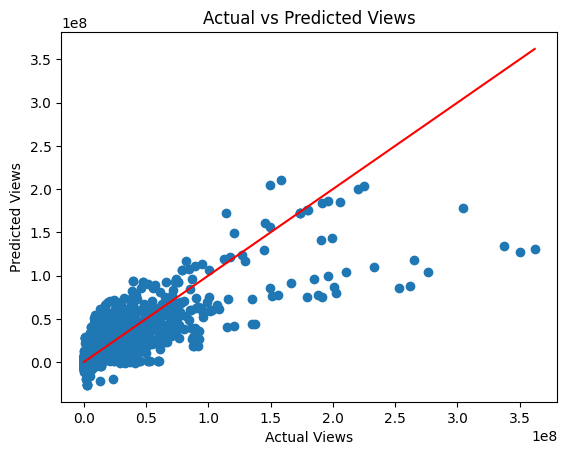

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.xlabel("Actual Views")
plt.ylabel("Predicted Views")
plt.title("Actual vs Predicted Views")
plt.show()

**Comparison Between Actual and Predicted Values**

The chart illustrates the relationship between the actual and predicted values generated by the model. The data points tend to follow the diagonal line, indicating that the model has captured the general pattern in the data and provides reasonably accurate predictions.

However, the points are still widely scattered around the diagonal line, particularly at higher values. This suggests that the model is not fully accurate, especially when predicting videos with very high view counts. The result highlights that predicting video views is a complex task influenced by multiple factors that the current model may not fully capture.



***Model Evaluation***

The model evaluation results show that:

* The R² score is approximately 0.71, indicating that the model can explain around 71% of the variance in the target variable, `views`. This is a relatively good result for a video view prediction task, which typically involves a high level of variability.

* The MSE value is relatively large because the `views` variable contains large values and follows a skewed distribution. This is expected and does not necessarily indicate poor overall model performance.

Overall, the Linear Regression model has successfully captured important relationships between the variables and can provide reasonably accurate predictions of video view counts.


#***Conclusion***

In this study, data on trending YouTube videos was analyzed to investigate the factors that influence video view counts.

Through exploratory data analysis (EDA), several important insights were identified. The distribution of views was right-skewed, indicating that only a small number of videos achieved highly viral performance, while most videos received relatively low view counts. Engagement-related factors, such as likes and comment count, showed strong relationships with views, suggesting that audience interaction plays an important role in increasing a video’s popularity.

In addition, video content category also had a significant influence on performance. Certain categories, such as music, tended to generate higher view counts. The time-based analysis showed that content creators usually uploaded more videos on weekdays; however, view performance was not always directly proportional to the number of videos published.

For the Machine Learning component, a Linear Regression model was used to predict video views based on the engineered features. The model achieved an R² score of approximately 0.71, indicating that it was able to explain a relatively large proportion of the variation in the data. However, prediction errors still remained, particularly for videos with extremely high view counts.

Overall, video view prediction is influenced by multiple factors, including audience engagement, content category, and publication timing. Therefore, combining a broader range of features is necessary to better understand the underlying patterns in the data.


#***Recommendations***

Based on the analysis results, several strategies can be recommended to optimize video performance on YouTube:

* **Optimize audience engagement:** Focus on increasing likes and comments through engaging content, clear calls to action, and active interaction with viewers, as these factors are strongly associated with video views.

* **Choose suitable content categories:** Categories such as music and entertainment tend to achieve higher view counts. Therefore, selecting the right type of content can improve the likelihood of a video going viral.

* **Optimize video publication timing:** Although creators tend to upload more videos on weekdays, days with lower competition, such as weekends, may still offer good opportunities. Testing different publication times can help identify the most effective schedule for maximizing views.

* **Prioritize quality over quantity:** The results indicate that publishing more videos does not necessarily lead to better performance. Therefore, investing in content quality is more important than simply increasing upload frequency.

* **Optimize titles and thumbnails:** Video titles and thumbnails play an important role in attracting viewers and encouraging clicks. Using clear, compelling titles and visually appealing thumbnails can improve the click-through rate and increase overall views.
